In [76]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

In [77]:
X= pd.read_csv("../data/X_processed.csv", index_col=0)
y = pd.read_csv("../data/y_labels.csv", index_col=0).squeeze()

In [78]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Scale AFTER split to prevent data leakage
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), index=X_train.index, columns=X_train.columns)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      index=X_test.index,  columns=X_test.columns)

print(f"Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}")
print(f"Train label distribution:\n{y_train.value_counts()}")

Train: (46, 2000), Test: (12, 2000)
Train label distribution:
char0+disease state
1    32
0    14
Name: count, dtype: int64


In [79]:
# Logistic Regression with L2 regularization
lr = LogisticRegression(max_iter=1000, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_cv_scores = cross_val_score(lr, X_train_scaled, y_train, cv=cv, scoring="accuracy")
print(f"LR CV accuracy: {lr_cv_scores.mean():.3f} ± {lr_cv_scores.std():.3f}")

lr.fit(X_train_scaled, y_train)
print("\nTest set report (Logistic Regression):")
print(classification_report(y_test, lr.predict(X_test_scaled), target_names=["SCC", "Adeno"]))

LR CV accuracy: 0.913 ± 0.083

Test set report (Logistic Regression):
              precision    recall  f1-score   support

         SCC       1.00      1.00      1.00         4
       Adeno       1.00      1.00      1.00         8

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12



In [80]:
# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)

rf_cv_scores = cross_val_score(rf, X_train_scaled, y_train, cv=cv, scoring="accuracy")
print(f"RF CV accuracy: {rf_cv_scores.mean():.3f} ± {rf_cv_scores.std():.3f}")

rf.fit(X_train_scaled, y_train)
print("\nTest set report (Random Forest):")
print(classification_report(y_test, rf.predict(X_test_scaled), target_names=["SCC", "Adeno"]))

RF CV accuracy: 0.913 ± 0.083

Test set report (Random Forest):
              precision    recall  f1-score   support

         SCC       1.00      0.75      0.86         4
       Adeno       0.89      1.00      0.94         8

    accuracy                           0.92        12
   macro avg       0.94      0.88      0.90        12
weighted avg       0.93      0.92      0.91        12



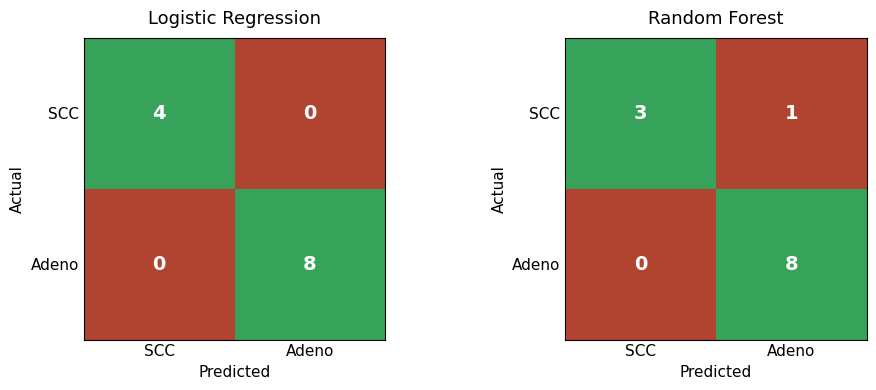

In [81]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
rdbrngn = LinearSegmentedColormap.from_list('rdbrngn', ['#c0392b', '#27ae60'])
diag_mask = np.eye(2, dtype=bool)
color_matrix = np.where(diag_mask, 0.9, 0.1)
for ax, model, name in zip(axes, [lr, rf], ["Logistic Regression", "Random Forest"]):
    cm = confusion_matrix(y_test, model.predict(X_test_scaled))

    im = ax.imshow(color_matrix, cmap=rdbrngn, vmin=0, vmax=1, interpolation='nearest')

    # cell labels
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]),
                    ha="center", va="center", fontsize=14, fontweight="bold",
                    color="white")

    # axis labels and ticks
    ax.set_xticks([0,1])
    ax.set_yticks([0,1])
    ax.set_xticklabels(["SCC","Adeno"], fontsize=11)
    ax.set_yticklabels(["SCC","Adeno"], fontsize=11)
    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("Actual", fontsize=11)
    ax.set_title(name, fontsize=13,pad=10)

    ax.tick_params(which="both",length=0)
    ax.grid(False)

plt.tight_layout()
plt.savefig("../figures/confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

In [82]:
# Feature importance
importances = rf.feature_importances_
std = pd.Series(np.std([tree.feature_importances_ for tree in rf.estimators_], axis=0), index=X.columns.tolist())
forest_importances = pd.Series(importances, index=X.columns.tolist())
forest_importances = forest_importances.sort_values(ascending=True).tail(20)

std = std[forest_importances.index]

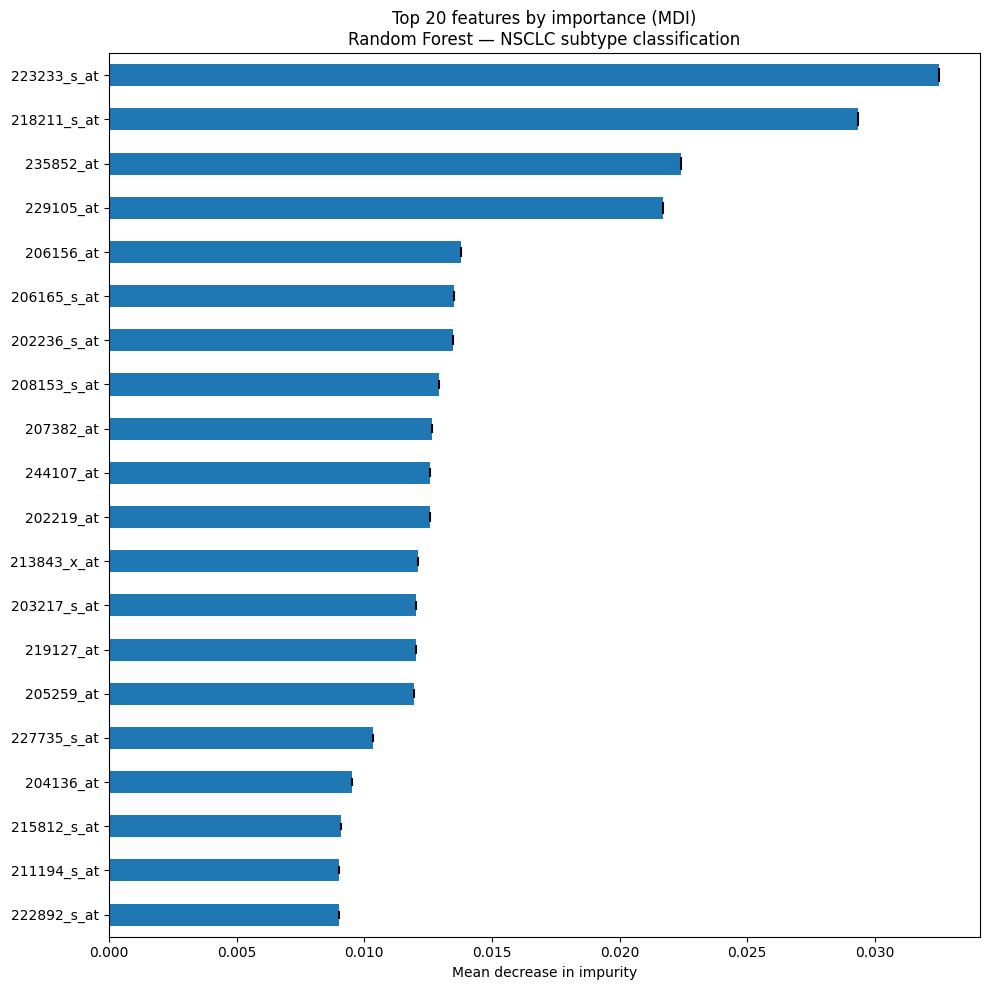

In [83]:
fig, ax = plt.subplots(figsize=(10,10))
forest_importances.plot.barh(yerr=std, ax=ax)
ax.set_title("Top 20 features by importance (MDI)\nRandom Forest — NSCLC subtype classification")
ax.set_xlabel("Mean decrease in impurity")
fig.tight_layout()

In [84]:
top_features = forest_importances.index.tolist()

permutations = permutation_importance(rf, X_test_scaled, y_test, n_repeats=10, scoring='roc_auc', n_jobs=-1)

In [85]:
forest_permutations = pd.Series(permutations.importances_mean, index=X.columns.tolist())
forest_permutations = forest_permutations[top_features].sort_values(ascending=True)
perm_std = pd.Series(permutations.importances_std, index=X.columns.tolist())
perm_std = perm_std[forest_permutations.index]

In [86]:
# forest_permutations = forest_permutations.sort_values(ascending=True).tail(20)
print(forest_permutations)

y_proba = rf.predict_proba(X_test_scaled)[:, 1]
print(y_proba.min(), y_proba.max())


222892_s_at    0.0
211194_s_at    0.0
215812_s_at    0.0
204136_at      0.0
227735_s_at    0.0
205259_at      0.0
219127_at      0.0
203217_s_at    0.0
213843_x_at    0.0
202219_at      0.0
244107_at      0.0
207382_at      0.0
208153_s_at    0.0
202236_s_at    0.0
206165_s_at    0.0
206156_at      0.0
229105_at      0.0
235852_at      0.0
218211_s_at    0.0
223233_s_at    0.0
dtype: float64
0.105 0.925
